<a href="https://colab.research.google.com/github/EmiiGit/NumLabIMC/blob/main/TP1IMC2024_CALDERON_JALIL_STEFANINI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introducción al modelado continuo** (*a.k.a.* **Ecuaciones de la física matemática**) - 2do Cuatrimestre 2024
# **Trabajo Práctico 1**

Este es el trabajo práctico del 1er eje temático. Se trata de un conjunto de ejercicios que deben resolver numéricamente y entregar para el **martes 22 de octubre, inclusive**. El trabajo se puede hacer en **grupos de hasta 3 personas**. Deben desarrollar los ejercicios en una **notebook** de Python en Google Colab. Deben **compartir el link del archivo final** (previamente dando permisos para compartir como lector), alojado en el Google Drive de alguno de los integrantes del grupo, y mandar el link del archivo al mail *hbocaccio@gmail.com*. Deben **enviar un único mail por grupo**. El nombre del archivo debe incluir los apellidos de los integrantes del grupo separados con guión bajo, resultando el siguiente **formato “TP1IMC2024_APELLIDO1_APELLIDO2_APELLIDO3.ipynb”**.

El contenido del archivo debe incluir las celdas de código necesarias para responder las consignas, intercalando con celdas de texto en las que cuenten lo que hicieron de manera resumida. También deben incluir texto explicando los resultados obtenidos y cómo estos responden a las consignas planteadas. Se valorará cualquier tipo de discusión de los resultados en referencia a conceptos tanto de la parte numérica como de la parte dinámica. No es necesario que se extiendan mucho en las explicaciones, pero sí que muestren conocimientos adquiridos a lo largo de la cursada en referencia a los contenidos fundamentales de la materia.


---
# Ejercicio 1

Sea el siguiente sistema dinámico unidimensional

$$
\dot{x} = -x + S(\rho+cx)
$$

con

$$
S(\rho+cx)=\frac{1}{1+e^{-(\rho+cx)}}
$$

donde la función $S(\rho+cx)$ es la función sigmoidea con la entrada parametrizada en base a los parámetros $\rho$ y $c$.

1.1. Defina una función de Python que refleje los valores de la función sigmoidea en base a un valor de x, incluyendo la posibilidad de definir los parámetros como argumento de entrada. Considere por default los valores de parámetros para que el resultado sea la función $S(x)$.

1.2. Estudie gráficamente la incidencia de los parámetros $\rho$ y $c$ en la forma funcional de la sigmoidea. Qué efecto tiene cada parámetro?

1.3. Estudie gráficamente la posibilidad de existencia de puntos fijos del sistema para c=10.

1.4. Usando las herramientas numéricas, busque los puntos fijos del sistema para c=10 y distintos valores de $\rho$ elegidos criteriosamente en base al ejercicio anterior. Recuerde aplicar alguna estrategia para limpiar artefactos en las raíces encontradas si los hubiese, como por ejemplo, pedir que el campo vector evaluado en la raíz sea menor a una cierta cota tolerada. Analice su estabilidad a partir de la derivada numérica. Haga un diagrama de bifurcaciones para los valores de $\rho$ elegidos. Qué tipo de bifurcaciones encuentra?

1.5. Para c=10, elija 3 valores de $\rho$ que definan comportamientos del sistema cualitativamente distintos. Para cada uno de estos valores de $\rho$, estudie las soluciones del sistema, obtenidas de integrar con el método de Euler, para distintos valores iniciales. Cómo interpreta las trayectorias encontradas y cómo las relaciona con los resultados previos?


EJERCICIO 1.1

Los valores pode defecto para la función sigmoidea son 𝜌 = 0 y c = 1 asi que utilizaremos estos mismos para definir la función.


In [ ]:
import math

def sigmoidea(x,p=0,c=1):
  return 1/(1+math.exp(-(p+c*x)))

EJERCICIO 1.2

In [ ]:
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt
import math

def graficar_sigmoidea(p=0.0, c=1.0):
    x = np.linspace(-10, 10, 400)
    y = [sigmoidea(val, p, c) for val in x]

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, label=f'p={p}, c={c}', color='blue')
    plt.title('Función Sigmoidea Interactiva')
    plt.xlabel('x')
    plt.ylabel('σ(x)')
    plt.ylim(-0.1, 1.1)
    plt.grid(True)
    plt.legend()
    plt.show()

# creamos deslizadores para p(ro) y c
interact(
    graficar_sigmoidea,
    p=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1, description='p'),
    c=FloatSlider(value=1.0, min=-10.0, max=10.0, step=0.1, description='c')
)


interactive(children=(FloatSlider(value=0.0, description='p', max=10.0, min=-10.0), FloatSlider(value=1.0, des…

<function __main__.graficar_sigmoidea(p=0.0, c=1.0)>

Observamos que:

* $p$  desplaza horizontalmente la sigmoide. Un valor mayor de ρ mueve la curva hacia la izquierda, mientras que un valor menor de la mueve hacia la derecha.

* $c$ ajusta la pendiente de la curva. Un valor más alto de 𝑐 hace que la transición de 0 a 1 sea más abrupta (más inclinada), mientras que un valor más bajo de de la misma genera una transición más suave.



* Para $p = 0$, con $c \to \infty$, se parece a:
    
    f(x) =
    \begin{cases}
    0 & \text{si} \, x \leq 0, \\
    1 & \text{si} \, x > 0.
    \end{cases}
    
* Para $p = 0$, con $c \to -\infty$, se parece a:
    
    f(x) =
    \begin{cases}
    0 & \text{si} \, x \geq 0, \\
    1 & \text{si} \, x < 0.
    \end{cases}

* Analizamos el punto medio de la función: En este punto, la entrada a la función sigmoide es cero $(ρ+cx=0)$, y como sabemos, $S(0)= 1/2$. Este es el punto donde la sigmoide cambia más rápidamente, y ocurre justamente cuando $x = -p/c$.

\
* Para $c = 1$, con $p$ positivo se desplaza hacia la izquierda, y con $p$ negativo se desplaza hacia la derecha, tal que: $f(p=p,x=-p) = 1/2.$

\
* Para $c>1, p>0$, se corre a la izquierda y tiene una pendiente alta tal que se parece a :
\
    f(x) =
    \begin{cases}
    0 & \text{si} \, x \leq -p/c, \\
    1 & \text{si} \, x > -p/c.
    \end{cases}

* Para $c>1, p<0$, se corre a la derecha y tiene una pendiente alta tal que se parece a:

    f(x) =
    \begin{cases}
    0 & \text{si} \, x \leq -p/c, \\
    1 & \text{si} \, x > -p/c.
    \end{cases}
* Para $c<1, p>0$

  f(x) =
    \begin{cases}
    0 & \text{si} \, x \geq -p/c, \\
    1 & \text{si} \, x < -p/c.
    \end{cases}

* Para $c<1, p<0$

   f(x) =
    \begin{cases}
    0 & \text{si} \, x \geq -p/c, \\
    1 & \text{si} \, x < -p/c.
    \end{cases}


Es decir :
*  c<0 la sigmoidea se parece a:
    
    f(x)=   \begin{cases}
    0 & \text{si} \, x \geq -p/c, \\
    1 & \text{si} \, x < -p/c.
    \end{cases}


*  c>0 la sigmoidea se parece a:

    f(x) =
    \begin{cases}
    0 & \text{si} \, x \leq -p/c, \\
    1 & \text{si} \, x > -p/c.
    \end{cases}

* c cercano a 0, no pesa el termino con x y entonces la sigmoidea depende solo de p tal que s(x,p,c) se parece a$$ f(\rho)=\frac{1}{1+e^{-\rho}}$$





EJERCICIO 1.3

Para estudiar gráficamente la posibilidad de existencia de puntos fijos del sistema dado, hay que resolver la ecuación:  
$0 = -x + S(\rho + cx)$
que se puede reorganizar a que se puede reorganizar a:
$x = S(\rho + cx)$ . Es decir queremos visualizar cuando la función sigmoidea choca con la funcion y = x .


In [ ]:
def graficar_puntos_fijos(p=0):
    x = np.linspace(-10, 10, 400)
    y_sigmoidea = sigmoidea(x, p)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y_sigmoidea, label=f'S({p} + 10x)', color='red')

    plt.plot(x, x, label='y = x', color='black', linestyle='--') # Grafico la línea y = x

    plt.title('Existencia de Puntos Fijos para c=10')
    plt.xlabel('x')
    plt.ylabel('Valores de la función')
    plt.ylim(-0.1, 1.1)
    plt.axhline(0.5, color='gray', linestyle='--', label='y=0.5')
    plt.grid(True)
    plt.legend()
    plt.show()

# Crear deslizadores para p (rho)
interact(
    graficar_puntos_fijos,
    p=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1, description='p'),
)

interactive(children=(FloatSlider(value=0.0, description='p', max=10.0, min=-10.0), Output()), _dom_classes=('…

<function __main__.graficar_puntos_fijos(p=0)>

A medida que vamos aumentando el valor de p, el número de intersecciones con la recta  $y = x$  va cambiando de un punto fijo, a dos, luego a tres,a dos nuevamente y después de regreso a uno.
Observando como se comportan las intersecciones vemos que es es un ejemplo típico de bifurcación de pitchfork ya que nuestro sistema dinámico pasa de tener un único punto fijo estable a tener múltiples puntos fijos estables (y un punto fijo inestable) a medida que vamos variando el parámetro p.


EJERCICIO 1.4

En este ejercicio vamos a utilizar alguno de los métodos vistos en clase .Elejimos el de la secante.Como ya previamente vimos en nuestros graficos que para c = 10 la funcion es muy empinada , vamos a tener distintos casos de puntos fijos . Por ejemplo si tuviesemos p=0 , el unico punto fijo que tendriamos seria en x = 1 . La cantidad de puntos fijos va a depender exclusivamente del valor de p . Lo que si sabemos es que van a ser el 0 , el 1 , u otro valor entre estos dos .


El método de la secante, al igual que otros métodos iterativos para encontrar raíces (como Newton-Raphson), solo encuentra un punto fijo por cada ejecución, y cuál punto fijo encuentra depende de los puntos iniciales que utilicemos. Si hay varios puntos fijos, el método encontrará uno de ellos, pero no garantiza que encuentre todos.

In [ ]:
import numpy as np
# Función para encontrar el punto fijo S(x) - x
def f_punto_fijo(x, p, c=10):
    return sigmoidea(x, p, c) - x


def secante(f, a, b, N, p, c):
    a_n = a
    b_n = b
    for n in range(1, N+1):
        c_n = a_n - f(a_n, p, c) * (b_n - a_n) / (f(b_n, p, c) - f(a_n, p, c))
        f_c_n = f(c_n, p, c)

        # Revisar si hemos encontrado una raíz
        if abs(f_c_n) < 1e-7:
            return c_n

        # Actualización de los intervalos
        a_n = b_n
        b_n = c_n

    print("Se excedió el número de iteraciones máximo")
    return None


Como en el gráfico vimos que para valores de p menores que -5 ( aproximadeamente) el único punto fijo es 0 , y para valores mayores a este , el unico es el 1 vamos a dividir elalgoritmo en tres partes. Para el intervalo -10<= p <= -5 vamos a utilizar puntos iniciales mas cercanos al cero . Por otro lado para valores de p entre -5 <=p <= 10 vamos a utilizar valores iniciales mas cercanos al 1 . Como sabemos que para valores cercanos a p = -5 la recta y =x cruza en mas de un solo lugar a la sigmoidea , vamos a elejir otros valores iniciales para ver si nuestro algoritmo puede encontrar otros puntos fijos ademas del 0 y el 1 en estos intervalos . Esto de elejir distintas condiciones iniciales para distintos valores de p, además nos asegurará de que el metodo converja mas rapidamente a los puntos fijos.

In [ ]:
puntos_fijos = set()
valores_de_p = np.arange(-10, -5, 0.2)

for p in valores_de_p:
    a = -0.1
    b = 0.2
    epsilon = 1e-7  # Tolerancia
    max_iter = 10000  # Máximo número de iteraciones
    c = 10

    # Buscar el punto fijo de la función sigmoidea parametrizada para el valor de p
    root = secante(f_punto_fijo, a, b, max_iter, p, c)

    # Agregar el punto fijo al conjunto (si no es None)
    if root is not None:
        puntos_fijos.add(root)

# Mostrar el conjunto de puntos fijos encontrados
print('Puntos fijos encontrados:', puntos_fijos)


Puntos fijos encontrados: {4.534105721654136e-05, 0.0016870028075460252, 0.0001235471025259931, 0.000614643808944774, 0.00010113140783380678, 0.002535968918004681, 6.777005882769751e-05, 0.0004112543953456885, 0.005812747943043499, 0.001125115255784088, 0.004712195809521888, 0.0020676086311117946, 0.0003364800787133685, 0.0002253238011265279, 0.0005027209961647501, 0.00015093797629870564, 0.0002753350178346493, 8.278572373569948e-05, 0.0007516543451650973, 5.547929403109159e-05, 0.00018441160918741112, 0.003113578267683874, 0.0013773472360860631, 0.0009194612309804077, 0.0038274350413675653}


In [ ]:
puntos_fijos_2 = set()
valores_de_p_2 = np.arange(-3, 10, 0.2)

for p in valores_de_p_2:
    a = 0.8
    b = 1.1
    epsilon = 1e-7  # Tolerancia
    max_iter = 10000  # Máximo número de iteraciones
    c = 10

    # Buscar el punto fijo de la función sigmoidea parametrizada para el valor de p
    root = secante(f_punto_fijo, a, b, max_iter, p, c)

    # Agregar el punto fijo al conjunto (si no es None)
    if root is not None:
        puntos_fijos_2.add(root)

# Mostrar el conjunto de puntos fijos encontrados
print('Puntos fijos encontrados:', puntos_fijos_2)

Puntos fijos encontrados: {0.9990805415773221, 0.9992483468977212, 0.9993853567426635, 0.9995887457140004, 0.999497279249202, 0.9996635199700894, 0.9997246650039736, 0.9997746762086285, 0.9998155883951797, 0.9998490620256577, 0.9998763566217425, 0.9999445013310987, 0.9999972391109236, 0.9999999916723895, 0.9999795941325778, 0.9999908326277895, 0.9999984848207986, 0.9999949691575608, 0.9999994426048819, 0.9999999248431722, 0.9999999384667989, 0.999999958753067, 0.999999966229869, 0.9999545685273687, 0.9999998625489386, 0.999999907863862, 0.9999999496208793, 0.9999999723513564, 0.999999981466561, 0.9999999931819292, 0.9999888025988398, 0.999996627810959, 0.9999998321168161, 0.9999938552105432, 0.9999977395924988, 0.9999987594813993, 0.9999995436441802, 0.9999171711006013, 0.9999924945811155, 0.9999981493464549, 0.9999996263679282, 0.9999695533497104, 0.9999998874646316, 0.9999999382393282, 0.9999863229449293, 0.9999958811519978, 0.9999999898286335, 0.9999832940337199, 0.999999749547404, 

In [ ]:
puntos_fijos_3 = set()
valores_de_p_3 = np.arange(-5, -3, 0.2)

for p in valores_de_p_3:
    a = 0.2
    b = 0.5
    epsilon = 1e-7  # Tolerancia
    max_iter = 10000  # Máximo número de iteraciones
    c = 10

    # Buscar el punto fijo de la función sigmoidea parametrizada para el valor de p
    root = secante(f_punto_fijo, a, b, max_iter, p, c)

    # Agregar el punto fijo al conjunto (si no es None)
    if root is not None:
        puntos_fijos_3.add(root)

# Mostrar el conjunto de puntos fijos encontrados
print('Puntos fijos encontrados:', puntos_fijos_3)

Puntos fijos encontrados: {0.5, 0.4666335244490396, 0.3990628007836521, 0.43306384623953714, 0.3643441654450849, 0.3285041749711776, 0.29089670168101595, 0.25029723226541617, 0.20361447891099457, 0.12915437364277071}


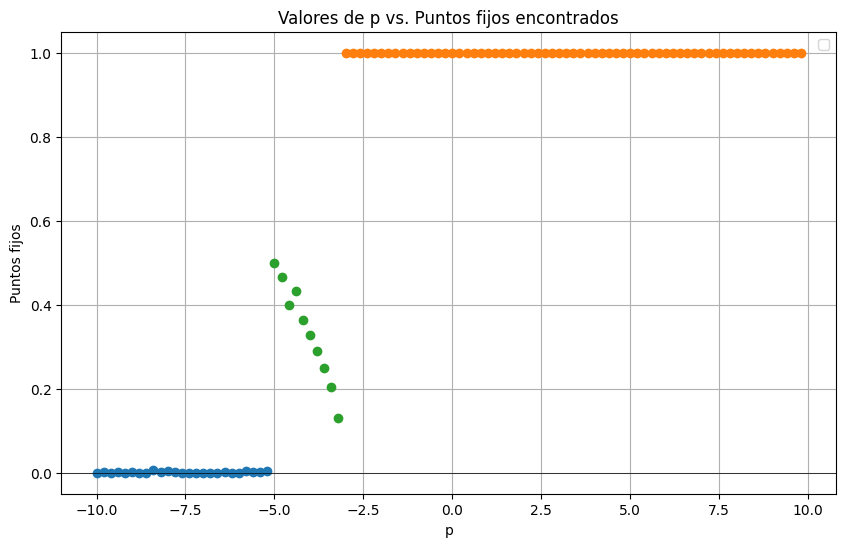

In [ ]:
# Filtrar los valores de p que tienen un punto fijo no nulo
p_filtrados = [p for p, root in zip(valores_de_p, puntos_fijos) if root is not None]
roots_filtrados = [root for root in puntos_fijos if root is not None]

p_filtrados_2 = [p for p, root in zip(valores_de_p_2, puntos_fijos_2) if root is not None]
roots_filtrados_2 = [root for root in puntos_fijos_2 if root is not None]

p_filtrados_3 = [p for p, root in zip(valores_de_p_3, puntos_fijos_3) if root is not None]
roots_filtrados_3 = [root for root in puntos_fijos_3 if root is not None]

# Crear el gráfico combinado
plt.figure(figsize=(10, 6))

# Gráfico de la primera serie de puntos
plt.plot(p_filtrados, roots_filtrados, 'o')

# Gráfico de la segunda serie de puntos
plt.plot(p_filtrados_2, roots_filtrados_2, 'o')

# Gráfico de la tercera serie de puntos
plt.plot(p_filtrados_3, roots_filtrados_3, 'o')

# Línea horizontal en y=0
plt.axhline(0, color='black', linewidth=0.5)

# Título y etiquetas
plt.title('Valores de p vs. Puntos fijos encontrados')
plt.xlabel('p')
plt.ylabel('Puntos fijos')
plt.grid(True)
plt.legend()
plt.show()


Podemos ver que el metodo encontro bien los puntos fijos x=0 y x=1 que eran los candidatos posibles, que sabiamos que eran estos observando los gráficos . Luego para algunos valores particulares de p , y condiciones iniciales especificas pudemos observar que el metodo encontro otro puntos fijos ademas del 0 y del 1 , como queriamos corroborar.

Ahora vamos a analizar la estabilidad de los puntos fijos a partir de la derivada numérica. Elejiremos algunos valores de p y haremos un diagrama de bifurcaciones para cada uno.Qué tipo de bifurcaciones encuentra?

In [ ]:
import sympy as sp

valores_de_p = [-10, -5, 0, 5, 10]

# Iterar para cada valor de p
for p in valores_de_p:
    c = 10
    x = sp.symbols('x')
    sistema = -x + 1 / (1 + sp.exp(-(p + c * x)))
    punto_fijo = secante(f_punto_fijo, -0.1, 1.1, 1000, p, c)
    sistema_derivado = sp.diff(sistema, x)
    derivada_en_punto_fijo = sistema_derivado.subs(x, punto_fijo).evalf()
    estabilidad = ""
    if derivada_en_punto_fijo > 0 :
      estabilidad = "inestable"
    else:
      estabilidad = "estable"

    print(f"Para p = {p}, el punto fijo es: {punto_fijo} y es {estabilidad}")

Para p = -10, el punto fijo es: 4.5463485671692894e-05 y es estable
Para p = -5, el punto fijo es: 0.5000000000000002 y es inestable
Para p = 0, el punto fijo es: 0.9999546129754593 y es estable
Para p = 5, el punto fijo es: 0.9999996923752594 y es estable
Para p = 10, el punto fijo es: 0.9999999979387685 y es estable


DIagramas de bifurcaciones para distintos valores de p : FALTA HACER

EJERCICIO 1.5

Para c=10, elija 3 valores de  ρ  que definan comportamientos del sistema cualitativamente distintos. Para cada uno de estos valores de  ρ , estudie las soluciones del sistema, obtenidas de integrar con el método de Euler, para distintos valores iniciales. Cómo interpreta las trayectorias encontradas y cómo las relaciona con los resultados previos?

Para c=10 vamos a elejir valores de p tales que el sistema se comporte de manera cualitativamente distinta. Vamos a elejir p = -10 , el cual nos daba un punto fijo unico estable en x=0 , con p = -4.70 tenemos 3 puntos fijos , y con p = 10 unicamente tenemos un punto fijo estable en x = 1 .


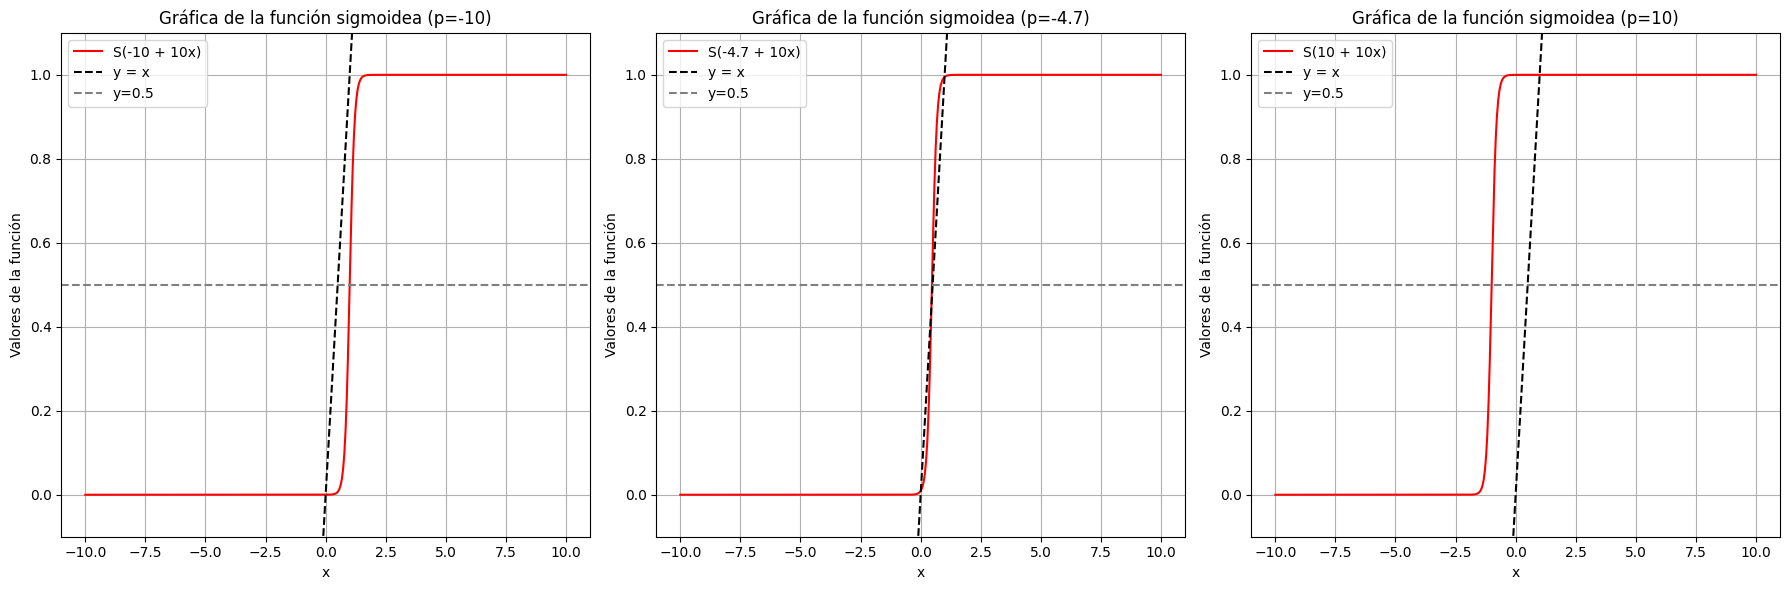

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoidea(x, p, c=10):
    return 1 / (1 + np.exp(-(p + c * x)))

def graficar_sigmoidea_y_recta(p_values):
    x = np.linspace(-10, 10, 400)  # Rango de valores para x

    # Crear una figura y subgráficas
    fig, axs = plt.subplots(1, len(p_values), figsize=(18, 6))  # Una fila, múltiples columnas

    for ax, p in zip(axs, p_values):
        y_sigmoidea = sigmoidea(x, p)

        ax.plot(x, y_sigmoidea, label=f'S({p} + 10x)', color='red')  # Graficar la sigmoidea
        ax.plot(x, x, label='y = x', color='black', linestyle='--')  # Graficar la línea y=x

        ax.set_title(f'Gráfica de la función sigmoidea (p={p})')
        ax.set_xlabel('x')
        ax.set_ylabel('Valores de la función')
        ax.set_ylim(-0.1, 1.1)  # Limitar el eje y
        ax.axhline(0.5, color='gray', linestyle='--', label='y=0.5')  # Línea horizontal en y=0.5
        ax.grid(True)
        ax.legend()

    plt.tight_layout()  # Ajustar el espaciado entre subgráficas
    plt.show()

# Llamar a la función con los parámetros deseados
graficar_sigmoidea_y_recta(p_values=[-10, -4.7, 10])


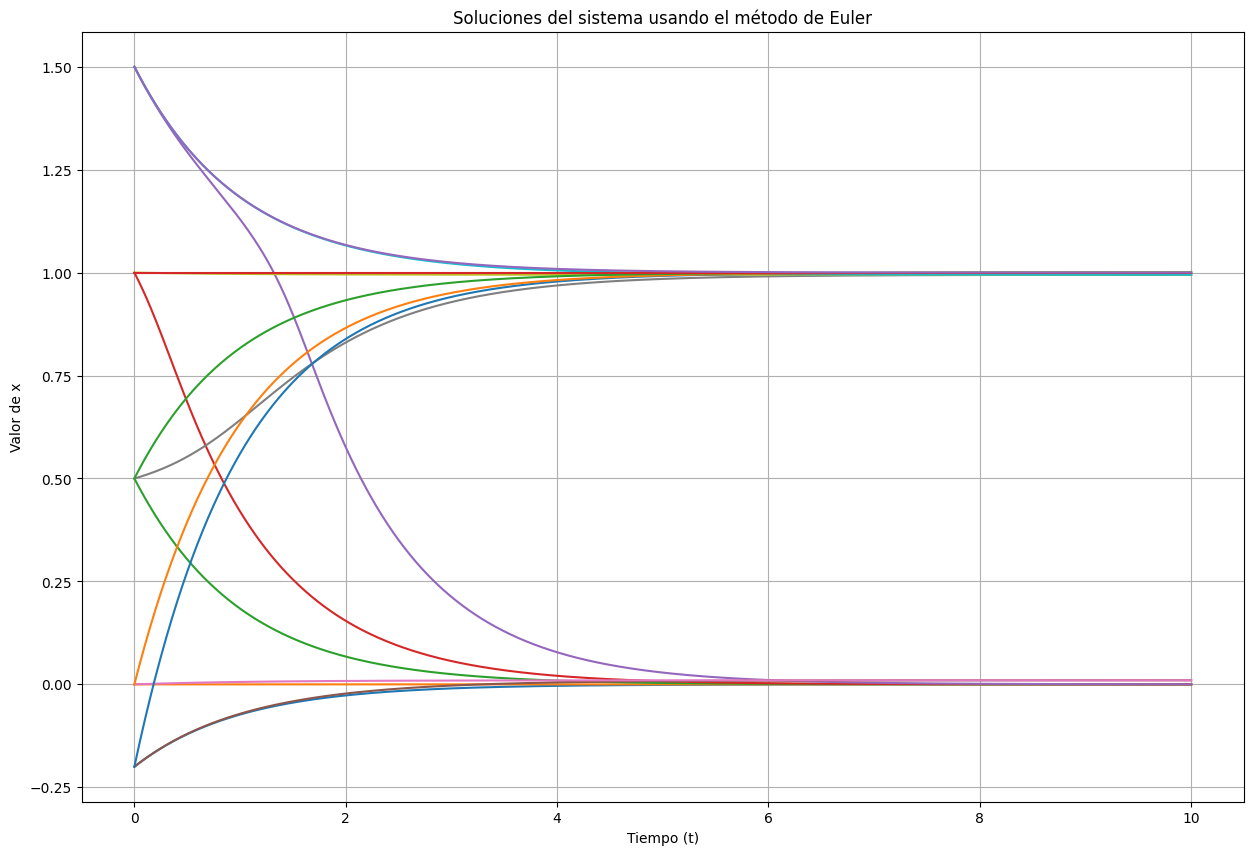

In [ ]:
# Definimos la función sigmoidea S
def S(value):
    return 1 / (1 + np.exp(-value))

# Definimos la función del sistema
def dxdt(x, rho, c):
    return -x + S(rho + c * x)

# Implementación del método de Euler
def euler_method(dxdt, x0, rho, c, t0, tf, dt):
    steps = int((tf - t0) / dt)
    t_values = np.linspace(t0, tf, steps)
    x_values = np.zeros(steps)

    # Condición inicial
    x_values[0] = x0

    for i in range(1, steps):
        x_values[i] = x_values[i - 1] + dxdt(x_values[i - 1], rho, c) * dt

    return t_values, x_values

# Estudiar las soluciones para diferentes valores de rho y condiciones iniciales
rho_values = [-10, -4.7, 10]  # Diferentes valores de rho
initial_conditions = [-0.2, 0,0.5,1,1.5]  # Diferentes condiciones iniciales
c = 10  # Valor de c
t0 = 0
tf = 10
dt = 0.01

# Graficar las soluciones
plt.figure(figsize=(15, 10))

for rho in rho_values:
    for x0 in initial_conditions:
        t_values, x_values = euler_method(dxdt, x0, rho, c, t0, tf, dt)
        plt.plot(t_values, x_values, label=f'ρ={rho}, x0={x0}')

plt.title('Soluciones del sistema usando el método de Euler')
plt.xlabel('Tiempo (t)')
plt.ylabel('Valor de x')
plt.grid()
plt.show()


Analizando el gráfico podemos ver como las trayectorias tienden a los puntos fijos ( x= 0 y x = 1) de manera que las lineas convergen cuando t aumenta a los mismos para distintas condicines iniciales. Como las trayectorias cercanas convergen hacia los puntos fijos , podemos concluir que estos puntos son estables.

---
# Ejercicio 2

Sea el siguiente sistema 2D

$$
\dot{x} = - x - x^{2} - y \\
\dot{y} = x - y
$$

2.1. Defina el sistema con una función de Python.

2.2. Busque puntos fijos a partir del estudio gráfico de las nulclinas. Para el gráfico de las nulclinas use `plt.contour` para levels=[0].

2.3. Busque numéricamente los puntos fijos con `fsolve` de Scipy.

2.4. Defina una función de Python genérica que tenga la matriz Jacobiana en función de valores de "x" e "y". Evalúe la matriz en los puntos fijos y estudie su estabilidad. Qué tipo de puntos fijos son?

2.5. Grafique el campo vector usando `plt.streamplots`. Interprete las líneas de campo obtenidas en referencia al item anterior.

2.6. Encuentre trayectorias en el espacio de fases que describan comportamientos del sistema. Para esto resuelva el sistema, usando `solve_ivp`. Use pasos largos, tiempos de integración muy cortos. Elija estos valores y las condiciones iniciales criteriosamente, de manera tal de reforzar los resultados previos, mostrando qué tipos de elementos dinámicos presenta el sistema en base a sus observaciones.

EJERCICIO 2.1

In [ ]:
import numpy as np

def sistema(t, variables):
    x, y = variables
    dx_dt = -x - x**2 - y
    dy_dt = x - y
    return [dx_dt, dy_dt]


EJERCICIO 2.2

<ipython-input-64-1f4ea018bec7>:15: UserWarning: The following kwargs were not used by contour: 'label'
  contour1 = plt.contour(X, Y, Z1, levels=[0], colors='blue', linewidths=2, label='dx/dt = 0')
<ipython-input-64-1f4ea018bec7>:16: UserWarning: The following kwargs were not used by contour: 'label'
  contour2 = plt.contour(X, Y, Z2, levels=[0], colors='red', linewidths=2, label='dy/dt = 0')


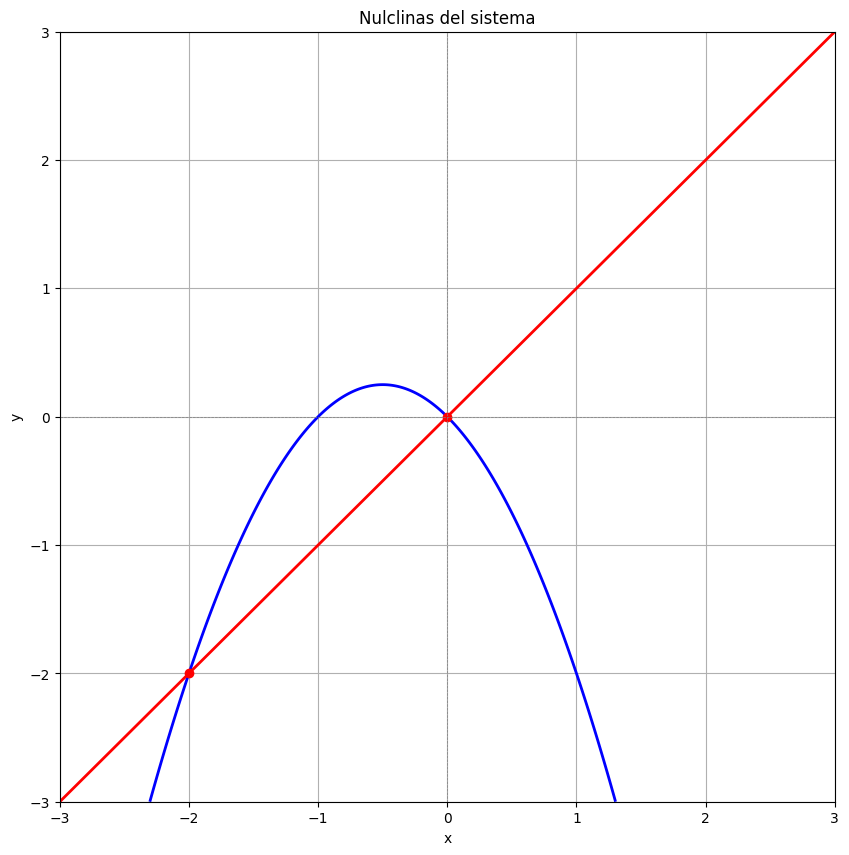

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos el rango para x y y
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

# Definimos las ecuaciones para las nulclinas
Z1 = -X - X**2 - Y  # dx/dt = 0
Z2 = X - Y          # dy/dt = 0

# Graficar las nulclinas
plt.figure(figsize=(10, 10))
contour1 = plt.contour(X, Y, Z1, levels=[0], colors='blue', linewidths=2, label='dx/dt = 0')
contour2 = plt.contour(X, Y, Z2, levels=[0], colors='red', linewidths=2, label='dy/dt = 0')

# Añadir etiquetas y título
plt.title('Nulclinas del sistema')
plt.xlabel('x')
plt.ylabel('y')

# Encontrar y marcar los puntos de intersección (puntos fijos)
intersections = []
x_fixed_values = []
y_fixed_values = []


# Puntos fijos analíticos
p1 = (0, 0)  # Primera solución (x = 0)
p2 = (-2, -2)  # Segunda solución (x = -2)

# Agregar los puntos fijos a la lista
intersections = [p1, p2]

# Graficar los puntos fijos
for (x_fixed, y_fixed) in intersections:
    plt.plot(x_fixed, y_fixed, 'ro')  # Puntos fijos en rojo

# Mostrar leyenda y rejilla
plt.axhline(0, color='gray', lw=0.5, ls='--')
plt.axvline(0, color='gray', lw=0.5, ls='--')
plt.grid()
plt.show()



Analizando graficamente las nulclinas , podemos observar que estas mismas se intersecan en los puntos (-2,-2) y (0,0).Por lo tanto estos seran los puntos fijos del sistema.

EJERCICIO 2.3

Vamos a encontrar los puntos fijos de manera analítica utilizando fsolve . Como analizando las nulclinas podemos concluir cuales son los puntos fijos vamos a poner estimaciones iniciales cercanas a dichos puntos para que fsolve funcione correctamente.

In [ ]:
import numpy as np
from scipy.optimize import fsolve

# Definir el sistema de ecuaciones sin la dependencia de tiempo
def sistema_sin_t(variables):
    x, y = variables
    dx_dt = -x - x**2 - y
    dy_dt = x - y
    return [dx_dt, dy_dt]

# Suposiciones iniciales para encontrar los puntos fijos
sup_i = [(0.1, 0.1), (-2.1, -2.1), (0.5, 0.5)]

puntos_fijos = []
for i in sup_i:
    solucion = fsolve(sistema_sin_t, i)  # Llamamos a sistema_sin_t, sin la variable de tiempo
    puntos_fijos.append(solucion)

# Imprimir los puntos fijos con más precisión (sin redondear)
for idx, punto in enumerate(puntos_fijos):
    x_rounded = round(punto[0], 5)
    y_rounded = round(punto[1], 5)
    print(f"Punto fijo {idx + 1}: ({x_rounded}, {y_rounded})")


Punto fijo 1: (0.0, 0.0)
Punto fijo 2: (-2.0, -2.0)
Punto fijo 3: (0.0, 0.0)


EJERCICIO 2.4

In [ ]:
import numpy as np
from scipy.optimize import fsolve
from numpy.linalg import eig

# Definir la matriz Jacobiana en función de x e y
def jacobiana(x, y):
    J = np.array([[-1 - 2*x, -1], [1, -1]])
    return J

puntos_fijos = [(0,0),(-2,-2)]

# Evaluar la matriz Jacobiana en los puntos fijos y estudiar la estabilidad
for idx, punto in enumerate(puntos_fijos):
    x_fijo, y_fijo = punto
    J = jacobiana(x_fijo, y_fijo)  # Evaluar la Jacobiana en el punto fijo
    autovalores, _ = eig(J)        # Calcular los autovalores de la Jacobiana

    print(f"Punto fijo {idx + 1}: ({round(x_fijo)}, {round(y_fijo)})")
    print(f"Jacobiana en el punto fijo:\n{J}")
    print(f"Autovalores: {autovalores}")

      # Clasificación de estabilidad
    if all(np.real(autovalores) < 0):
        print("El punto fijo es estable (nodo estable).\n")
    elif all(np.real(autovalores) > 0):
        print("El punto fijo es inestable (al menos un autovalor positivo).\n")
    else:
        print("El punto fijo es un punto silla (al menos un autovalor positivo y uno negativo).\n")



Punto fijo 1: (0, 0)
Jacobiana en el punto fijo:
[[-1 -1]
 [ 1 -1]]
Autovalores: [-1.+1.j -1.-1.j]
El punto fijo es estable (nodo estable).

Punto fijo 2: (-2, -2)
Jacobiana en el punto fijo:
[[ 3 -1]
 [ 1 -1]]
Autovalores: [ 2.73205081 -0.73205081]
El punto fijo es un punto silla (al menos un autovalor positivo y uno negativo).



La matriz jacobiana evaluada en el punto fijo (0,0) nos da autovalores imaginarios con parte real negaiva , asi que podemos concluir que estos son focos atractores . Por otra parte si evaluamos la matriz J en el (-2,-2) tenemos autovalores reales puros , uno positivo y otro negativo . Por lo que sabemos que es un punto silla . En una direccion se acerca ( direccion correspondiente al autovector del autovalor negativo) , y en la otra se alejan ( autovector correspondiente al autovalor positivo) .

EJERCICIO 2.5

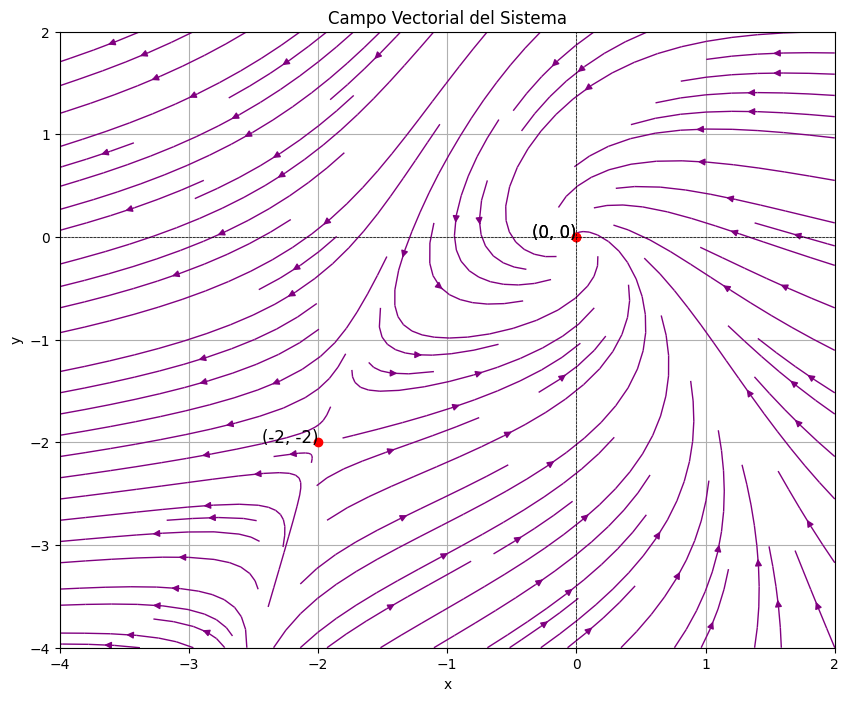

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from numpy.linalg import eig

# Definir el sistema de ecuaciones
def sistema(x, y):
    dxdt = -x - x**2 - y  # Ecuación dx/dt
    dydt = x - y          # Ecuación dy/dt
    return dxdt, dydt

# Crear una malla de puntos en el espacio
x_values = np.linspace(-4, 2, 20)  # Rango de x
y_values = np.linspace(-4, 2, 20)  # Rango de y
X, Y = np.meshgrid(x_values, y_values)  # Crear una malla

# Calcular dx/dt y dy/dt en cada punto de la malla
DX, DY = sistema(X, Y)

# Graficar el campo vectorial usando streamplot
plt.figure(figsize=(10, 8))
plt.streamplot(X, Y, DX, DY, color='purple', linewidth=1, density=1)

# Encontrar y graficar los puntos fijos
sup_i = [(0, 0), (-2, -2), (1, 1)]  # Suposiciones iniciales
puntos_fijos = [fsolve(lambda vars: sistema(vars[0], vars[1]), sup) for sup in sup_i ]

# Graficar los puntos fijos
for idx, punto in enumerate(puntos_fijos):
    plt.plot(punto[0], punto[1], 'ro')  # Puntos fijos en rojo
    plt.text(punto[0], punto[1], f'({round(punto[0])}, {round(punto[1])})', fontsize=12, ha='right')

plt.title('Campo Vectorial del Sistema')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-4, 2)
plt.ylim(-4, 2)
plt.grid()
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.show()


Se puede observar que en el punto (-2;-2) las lineas del campo de flujo se acercan en una dirección y en la otra se alejan. Tambien, en el punto (0;0) se ve que es un foco atractor ya que todas las lineas del campo se acercan a él en forma de espiral.

EJERCICO 2.6

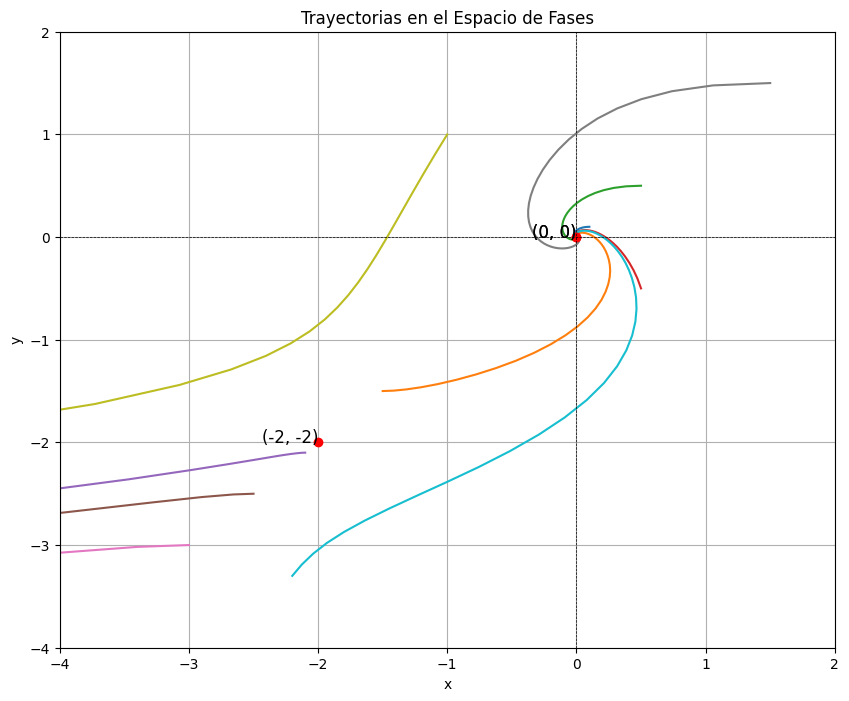

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# Definir el sistema de ecuaciones
def sistema(t, vars):
    x, y = vars
    dxdt = -x - x**2 - y  # Ecuación dx/dt
    dydt = x - y          # Ecuación dy/dt
    return [dxdt, dydt]

# Encontrar los puntos fijos usando fsolve
sup_iniciales = [(0, 0), (-2, -2), (1, 1)] # suposiciones iniciales
puntos_fijos = [fsolve(lambda vars: sistema(0, vars), sup) for sup in sup_iniciales]

# Definir condiciones iniciales
condiciones_iniciales = [
    (0.1, 0.1),
    (-1.5, -1.5),
    (0.5, 0.5),
    (0.5, -0.5),
    (-2.1, -2.1), (-2.5,-2.5), (-3,-3),
    (1.5, 1.5),
    (-1, 1), (-2.2, -3.3)
]

# Tiempo de integración
t_resolucion = (0, 10)  # Integrar de 0 a 10
t_eval = np.linspace(t_resolucion[0], t_resolucion[1], 100)  # Evaluar en 100 puntos

# Graficar las trayectorias
plt.figure(figsize=(10, 8))

for ic in condiciones_iniciales:
    sol = solve_ivp(sistema, t_resolucion, ic, t_eval=t_eval, method='RK45')
    plt.plot(sol.y[0], sol.y[1], label=f'Condición inicial: {ic}')

# Graficar los puntos fijos
for punto in puntos_fijos:
    plt.plot(punto[0], punto[1], 'ro')  # Puntos fijos en rojo
    plt.text(punto[0], punto[1], f'({round(punto[0])}, {round(punto[1])})', fontsize=12, ha='right')

plt.title('Trayectorias en el Espacio de Fases')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-4, 2)
plt.ylim(-4, 2)
plt.grid()
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.show()


---
# Ejercicio 3

**Modelo SIR**

Para modelar la evolución de una infección en una población se la puede dividir en tres grupos: los *susceptibles* de contraer la enfermedad ($S$), los *infectados* ($I$) y los *recuperados* ($R$). La relación entre el número de personas en cada grupo está definida por el siguiente sistema de ODEs:

$$
\frac{dS}{dt} = -\beta \frac{S\,I}{N}\\
\frac{dI}{dt} = \beta \frac{S\,I}{N} - \gamma\, I\\
\frac{dR}{dt} = \gamma\, I
$$

con $\beta$ y $\gamma$ las tasas de infección y recuperación respectivamente y $N$ la población total.

3.1. Considerar que la población de $N = 10000$ habitantes e inicialmente todas las personas son susceptibles. Supondremos una tasa de transmisión $\beta=0.2$ y un tiempo medio de recuperación de 10 días (es decir, una tasa $\gamma$ de 1/10). Si inicialmente hay una única persona enferma, discutir de qué forma deberían evolucionar las poblaciones de cada grupo. [Hint: considere que todas las personas que no están enfermas son susceptibles].

3.2. Asumiendo que no se producen fallecimientos, verificar que la población de la ciudad se mantiene constante a lo largo de la simulación.

3.3. Determinar el tiempo a partir del cual, sin acciones externas, la cantidad de infecciones llega a su máximo y comienza a descender (calcular, no hacer a ojo). Mostrar cuál sería ese momento en la curva de I(t).

---

EJERCICIO 3.1

Inicialmente tenemos 1 infectado, ningún recuperado y 9999 suceptibles. A medida que el infcectado interactué con los suceptibles, la cantidad de afectados aumentará correspondiéndose con la tasa de trasmisión. Mientras crecen los infectados, disminuyen los suceptibles(ya que contrajeron la enfermedad) y aumentan los recuperados. A mayor cantidad de infectados, mayor será la cantidad de recuperados a futuro(asumimos que no mueren y siempre se recuperan) y menor la cantidad de suceptibles(suponemos que desarrollan algun mecanismo de inmunidad). Entonces en t=0, tenemos muchos suceptibles, pocos infectados, ningún recuperado. En t final tenemos muchos recuperados, ningún enfermo y ningún suceptible. Mientras t no sea 0 o final(es decir, mientras haya cambios en el sistema), la cantidad de suceptibles decrece(en la ecuación tiene un coeficiente negativo), la de enfermos crece hasta su máximo y luego decrece(tiene un termino positivo y uno negativo, $$\beta \frac{S\,I}{N} \geq \gamma\, I $$


hasta un cierto t y luego esta desigualdad se invierte y la de recuperados aumenta(la ecuación es positiva).

EJERCICIO 3.2

Si queremos que la población se mantenga constante, queremos que la suma de las ODES que la modelan sea 0 tal que los cambios en los grupos poblacionales se vayan compensando entre sí. Luego:

$$
\frac{dS}{dt} + \frac{dI}{dt} + \frac{dR}{dt}
 = -\beta \frac{S\,I}{N}\ +\beta \frac{S\,I}{N} - \gamma\, I\ +\gamma\, I =0
$$

Podemos observar claramente que los terminos se cancelan entre sí tal por lo que la cuenta da efectivamente 0. Por lo tanto si asumimos las condiciones propuestas, la pobalción se mantiene constante.

EJERCICIO 3.3

Para determinar el momento en el cual la cantidad de infecciones I(t) alcanza su máximo, tenemos que analizar el punto en el que la tasa de cambio de I(t) ,se vuelve igual a cero. Este será el instante en el que I(t) deja de aumentar y comienza a disminuir.

A partir de la ecuación diferencial para I(t):
$$
\frac{dI}{dt} = \beta \frac{S\,I}{N} - \gamma\, I\
$$

Para encontrar el máximo de I(t), establecemos la condición de que
𝑑𝐼/𝑑𝑡=0 por lo que nos queda :

$$
\beta \frac{S\,I}{N} = \gamma\, I\
$$

Podemos simplificar eliminando I (que no es cero en el máximo claramente):

$$
\beta \frac{S\,}{N} = \gamma\, \
$$

Además sabemos que
$$\beta =0.2 , \gamma = 0.1 $$


y N dijimos que se mantiene constante: N=10000. Nuestra única incógnita es S, calculemoslo y luego averigüemos el t asociado.

$$0.2 \frac{S}{10000} = 0.1 \iff S=5000$$.

Este valor indica que el número de susceptibles S(t) cuando I(t) alcanza su máximo es 5000.

Ahora que sabemos que S(t) debe alcanzar 5000 en el momento en que I(t) es máximo, podemos encontrar el tiempo exacto resolviendo las ecuaciones diferenciales del modelo SIR. Esto se puede hacer numéricamente utilizando e metodo visto en clase de Runge-Kutta. Lo que haremos es resolver el sistema de ecuaciones diferenciales con las siguientes condiciones iniciales :    
S(0)=9999    
I(0)=1   
R(0)=0

Buscaremos el momento en el que S(t)=5000, ya que es cuando I(t) será máximo.

Utilizaremos el codigo visto en clase :

In [ ]:
# Primero aclararemos cuales son los parámetros del modelo y las condiciones iniciales :
beta = 0.2
gamma = 1/10
N = 10000
I0 = 1
S0 = N - I0
R0 = 0  # inicialmente, no hay recuperados
y0 = [S0, I0, R0]  # estado inicial

In [ ]:
# Vamos a definir como es nuestro sistema :
def sir_system(y, t, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return np.array([dSdt, dIdt, dRdt])

In [ ]:
# Utilizamos la funcion vista en clase:
def rk4(dxdt, x, t, dt, *args, **kwargs):
    x = np.asarray(x)
    k1 = np.asarray(dxdt(x, t, *args, **kwargs))*dt
    k2 = np.asarray(dxdt(x + k1*0.5, t, *args, **kwargs))*dt
    k3 = np.asarray(dxdt(x + k2*0.5, t, *args, **kwargs))*dt
    k4 = np.asarray(dxdt(x + k3, t, *args, **kwargs))*dt
    return x + (k1 + 2*k2 + 2*k3 + k4)/6

In [ ]:
# Simulación con RK4 usando un bucle for

def simulacion_rk4(y0, t, dt, beta, gamma, N):
    M = np.zeros((len(t), 3))  # Matriz para almacenar [S, I, R] en cada paso
    M[0] = y0  # Condición inicial

    for ix, tt in enumerate(t[:-1]):
        M[ix + 1] = rk4(sir_system, M[ix], tt, dt, beta, gamma, N)

    S, I, R = M[:, 0], M[:, 1], M[:, 2]
    return S, I, R


In [ ]:
dt = 1  # Paso de tiempo (1 día)
t = np.arange(0, 658 + dt, dt)  # Simulamos 160 días
# Ejecutar la simulación
S, I, R = simulacion_rk4(y0, t, dt, beta, gamma, N)

# Encontrar el tiempo en el que I(t) alcanza su máximo
t_max_infectados = t[np.argmax(I)]

print(t_max_infectados)

91


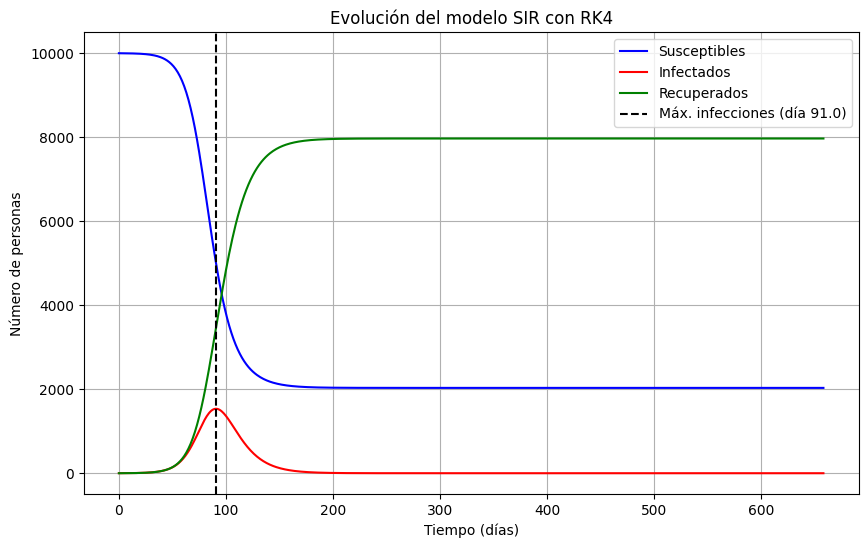

El número máximo de infectados ocurre alrededor del día 91.0


In [ ]:
# Graficar las curvas de S(t), I(t) y R(t)
plt.figure(figsize=(10, 6))
plt.plot(t, S, 'b', label='Susceptibles')
plt.plot(t, I, 'r', label='Infectados')
plt.plot(t, R, 'g', label='Recuperados')
plt.axvline(t_max_infectados, color='k', linestyle='--', label=f'Máx. infecciones (día {t_max_infectados:.1f})')
plt.xlabel('Tiempo (días)')
plt.ylabel('Número de personas')
plt.title('Evolución del modelo SIR con RK4')
plt.legend()
plt.grid(True)
plt.show()

print(f'El número máximo de infectados ocurre alrededor del día {t_max_infectados:.1f}')

Observacion : fuimos cambiando la cantidad de dias para hacer la simulación para ver como esto afectaba en el tiempo buscado y llegamos a la conclusion que no importa si poniamos muchos mas dias , el maximo siempre nos daba 91, luego haciendo el gráfico se puede observar que alli es donde alcanza el punto max y la función de infectados es acampanada y no vuelve a subir .